In [2]:
import os
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [3]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY is not set")


In [4]:
mem0_config = {
    "llm": {
        "provider": "groq",
        "config": {
            "model": "llama-3.3-70b-versatile",
            "api_key": os.environ["GROQ_API_KEY"],
            "temperature": 0,
        }
    },
    "embedder": {
        "provider": "huggingface",
        "config": {
            "model": "all-MiniLM-L6-v2",
        }
    },
    "vector_store": {

            "provider": "qdrant",
            "config": {
                "path": "./data/mem0-chroma",
                "embedding_model_dims": 384,
            }

    },

}

In [5]:
mem0_config

{'llm': {'provider': 'groq',
  'config': {'model': 'llama-3.3-70b-versatile',
   'api_key': 'REDACTED_GROQ_API_KEY',
   'temperature': 0}},
 'embedder': {'provider': 'huggingface',
  'config': {'model': 'all-MiniLM-L6-v2'}},
 'vector_store': {'provider': 'qdrant',
  'config': {'path': './data/mem0-chroma', 'embedding_model_dims': 384}}}

In [6]:
from mem0 import Memory

m = Memory.from_config(mem0_config)

/home/tiago/Documents/cursos&Projetos-udemy&youtube/krish naik academy/agenti-ai-customer-support/customer-support/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15622.66it/s]
/home/tiago/Documents/cursos&Projetos-udemy&youtube/krish naik academy/agenti-ai-customer-support/customer-support/.venv/lib64/python3.14/site-packages/mem0/embeddings/huggingface.py:27: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.config.embedding_dims = self.config.embedding_dims or self.model.get_sentence_embedding_dimension()


In [7]:
m

In [8]:
messages = [
    {"role": "user", "content": "Hello, how are you? I'm Tiago and i play soccer"},
    {"role": "assistant", "content": "Hey Tiago, how can I help you today?"},
]
m.add(messages, user_id="tiago")

{'results': []}

In [9]:
results = m.search("What do you know about me?", filters={"user_id": "tiago"})
print(results)

Failed to load spaCy lemma model: spaCy is not installed. Install it with: pip install mem0ai[nlp]
Failed to load spaCy full model: spaCy is not installed. Install it with: pip install mem0ai[nlp]
fastembed not installed — BM25 keyword search disabled. Install with: pip install fastembed


{'results': [{'id': 'a2fac739-26d1-4c87-a177-2f3e5dcde940', 'memory': "User's name is Tiago and plays soccer", 'hash': 'a6304be021cbe66e89647ace28c3d449', 'metadata': None, 'score': 0.1708527579410682, 'created_at': '2026-05-05T18:54:37.603600+00:00', 'updated_at': '2026-05-05T18:54:37.603600+00:00', 'user_id': 'tiago'}, {'id': 'cc11d962-c873-4693-af02-5530beea8528', 'memory': "User's name is Tiago", 'hash': '16cffc8d9767c94c49b96a540d49776b', 'metadata': None, 'score': 0.156355005795061, 'created_at': '2026-05-05T18:53:30.898059+00:00', 'updated_at': '2026-05-05T18:53:30.898059+00:00', 'user_id': 'tiago'}]}


In [15]:
messages = [
    {"role": "user", "content": "Hello, how are you? I'm Yash and love to play basketball"},
    {"role": "assistant", "content": "Hey Yash, how can I help you today?"},
]
m.add(messages, user_id="yash")

{'results': [{'id': 'f94ad5f9-78b3-464d-bbec-b05a5fa64f89',
   'memory': "User's name is Yash and they love to play basketball",
   'event': 'ADD'}]}

In [16]:
results = m.search("What do you know about me?", filters={"user_id": "yash"})
print(results)

{'results': [{'id': 'f94ad5f9-78b3-464d-bbec-b05a5fa64f89', 'memory': "User's name is Yash and they love to play basketball", 'hash': '99c722bfbb91b828dd3610b15401bd03', 'metadata': None, 'score': 0.14515578407883253, 'created_at': '2026-05-05T19:01:37.118478+00:00', 'updated_at': '2026-05-05T19:01:37.118478+00:00', 'user_id': 'yash'}]}


LANGCHAIN


In [5]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant", temperature=0, max_tokens=128)

llm_groq.invoke("Hello! im Tiago")

AIMessage(content='Nice to meet you, Tiago. Is there something I can help you with or would you like to chat?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 40, 'total_tokens': 64, 'completion_time': 0.031844831, 'completion_tokens_details': None, 'prompt_time': 0.003645636, 'prompt_tokens_details': None, 'queue_time': 0.019586003, 'total_time': 0.035490467}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1315-b289-7930-aedf-7211dee1fcdf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 40, 'output_tokens': 24, 'total_tokens': 64})

In [7]:
from langchain.agents import create_agent
from langchain.tools import tool

In [8]:
@tool
def dummy_tool(inputText:str) -> str:
    """convert input text to uppercase. this is just for testing 
        Arguments:
        inputText {str} -- input text to convert to uppercase
    
    """
    
    return f"Output: {inputText.upper()}"

In [9]:
my_tool = [dummy_tool]

In [10]:
my_agent = create_agent(model=llm_groq, tools=my_tool)

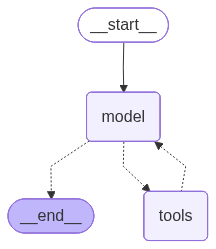

In [11]:
my_agent

In [14]:
res = my_agent.invoke({"messages": [("user", "hi, im tiago")]})

In [15]:
res

{'messages': [HumanMessage(content='hi, im tiago', additional_kwargs={}, response_metadata={}, id='7cf1b9e5-2908-44f0-8dab-38f85f95e125'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jzb6amdfk', 'function': {'arguments': '{"inputText":"hi, im tiago"}', 'name': 'dummy_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 261, 'total_tokens': 281, 'completion_time': 0.064356961, 'completion_tokens_details': None, 'prompt_time': 0.021068438, 'prompt_tokens_details': None, 'queue_time': 0.045823226, 'total_time': 0.085425399}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e131b-200a-74d2-8bee-b821ff828912-0', tool_calls=[{'name': 'dummy_tool', 'args': {'inputText': 'hi, im tiago'}, 'id': 'jzb6amdfk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'inpu

In [16]:
res_with_tool = my_agent.invoke({"messages": [("user", "hi, im tiago, and i want to convert `Ai agent` to uppercase")]})

In [17]:
res_with_tool

{'messages': [HumanMessage(content='hi, im tiago, and i want to convert `Ai agent` to uppercase', additional_kwargs={}, response_metadata={}, id='3a1ecb3c-143c-4af0-b0b3-581fa8316e0d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'q706q8h0d', 'function': {'arguments': '{"inputText":"Ai agent"}', 'name': 'dummy_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 273, 'total_tokens': 290, 'completion_time': 0.021464126, 'completion_tokens_details': None, 'prompt_time': 0.022026458, 'prompt_tokens_details': None, 'queue_time': 0.046054609, 'total_time': 0.043490584}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e131c-3951-78f1-9441-24a485849082-0', tool_calls=[{'name': 'dummy_tool', 'args': {'inputText': 'Ai agent'}, 'id': 'q706q8h0d', 'type': 'tool_call'}], inval